In [1]:
import sys
from pathlib import Path

# 🔑 Automatically locate project root by searching upward for the 'src' folder
project_root = Path.cwd()
while not (project_root / "src").exists() and project_root != project_root.parent:
    project_root = project_root.parent

# Insert at the front of sys.path so Python finds 'src' first
sys.path.insert(0, str(project_root))
print(f"✅ Project root resolved: {project_root}")

✅ Project root resolved: c:\Users\igor\Documents\GitHub\futures_trading_strategies


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from src import (
    load_simple_price_csv,
    FixedRiskPositionStrategy,
    BuyAndHoldStrategy,
    VectorizedEngine,
    plot_results,
    plot_backtest_results
)

In [3]:
data = load_simple_price_csv("../data/MCFTR.csv", date_format="%Y-%m-%d")
display(data.head())

2026-07-28 09:34:01.055 | INFO     | src.data.loader:load_simple_price_csv:47 - 📥 Loading simple price data: MCFTR.csv
2026-07-28 09:34:01.065 | INFO     | src.data.loader:load_simple_price_csv:81 - ✅ Loaded 5739 bars | Range: 2003-02-26 → 2026-02-13


,close
date,
2003-02-26,335.67
2003-02-27,338.35
2003-02-28,341.52
2003-03-03,352.24
2003-03-04,348.40


In [4]:
INITIAL_CAPITAL = 100000
VOLATILITY_WINDOW = 252
RISK_TARGET = 0.2
MULTIPLIER=1.0
MAX_LEVERAGE=1.0

In [5]:
strategy_fixed = FixedRiskPositionStrategy(volatility_window=VOLATILITY_WINDOW, risk_target=RISK_TARGET, max_leverage=MAX_LEVERAGE)
strategy_risky = FixedRiskPositionStrategy(volatility_window=VOLATILITY_WINDOW, risk_target=0.4, max_leverage=MAX_LEVERAGE)

In [6]:
engine = VectorizedEngine(
    initial_capital=INITIAL_CAPITAL,     
    commission_rate=0.0004,
    slippage_rate=0.001
)

In [7]:
strategy_fixed_result = engine.run(strategy_fixed, data)
strategy_risky_result = engine.run(strategy_risky, data)

In [8]:
strategy_fixed_result.print_summary()

┌──────────────────────────────────────────────────────────────────────
│ Strategy: FixedRiskPositionStrategy                │ Instrument               │
├──────────────────────────────────────────────────────────────────────┤
│ Years of data                            │                     22.8 │
│ Mean annual return                       │                    +6.0% │
│ Average drawdown                         │                    -1.6% │
│ Maximum drawdown                         │                   -26.5% │
│ Annualised standard deviation            │                     9.2% │
│ Sharpe ratio                             │                     0.65 │
│ Skew                                     │                     0.00 │
│ Lower tail                               │                     2.33 │
│ Upper tail                               │                     1.95 │
└──────────────────────────────────────────────────────────────────────┘


In [9]:
strategy_risky_result.print_summary()

┌──────────────────────────────────────────────────────────────────────
│ Strategy: FixedRiskPositionStrategy                │ Instrument               │
├──────────────────────────────────────────────────────────────────────┤
│ Years of data                            │                     22.8 │
│ Mean annual return                       │                    +6.5% │
│ Average drawdown                         │                    -1.7% │
│ Maximum drawdown                         │                   -29.1% │
│ Annualised standard deviation            │                    10.0% │
│ Sharpe ratio                             │                     0.65 │
│ Skew                                     │                     0.00 │
│ Lower tail                               │                     2.56 │
│ Upper tail                               │                     2.17 │
└──────────────────────────────────────────────────────────────────────┘


c:\Users\igor\Documents\GitHub\futures_trading_strategies\src\plots\plotting.py:97: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


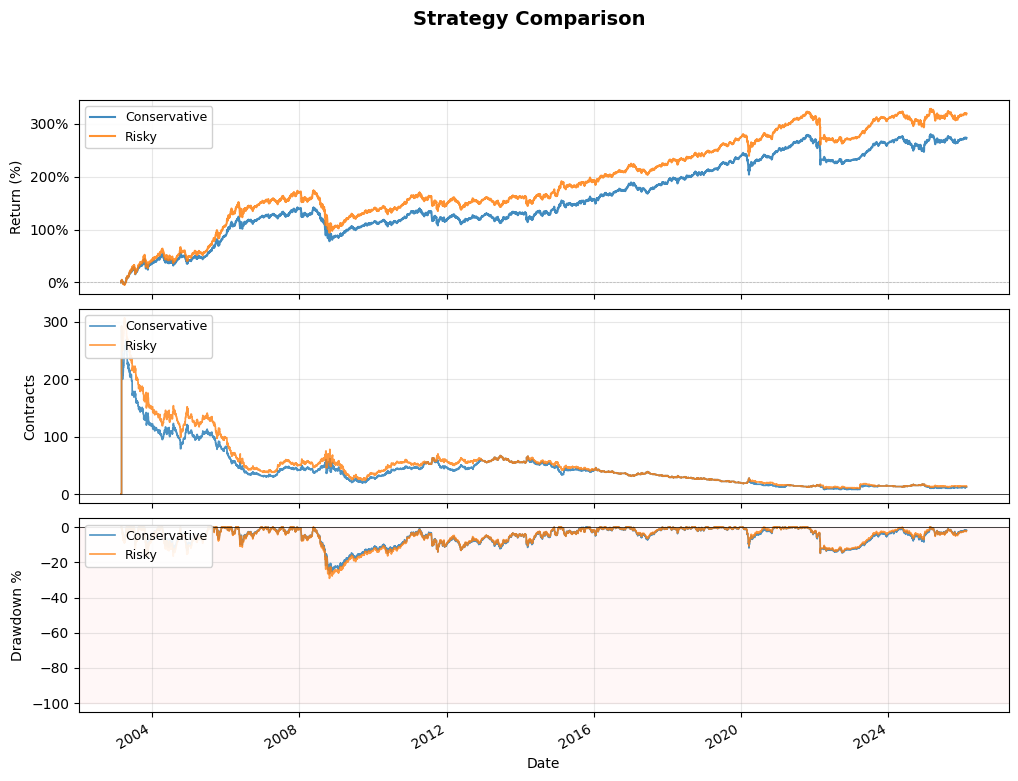

In [10]:
plot_results({"Conservative": strategy_fixed_result, "Risky": strategy_risky_result}, plot_pct=True)

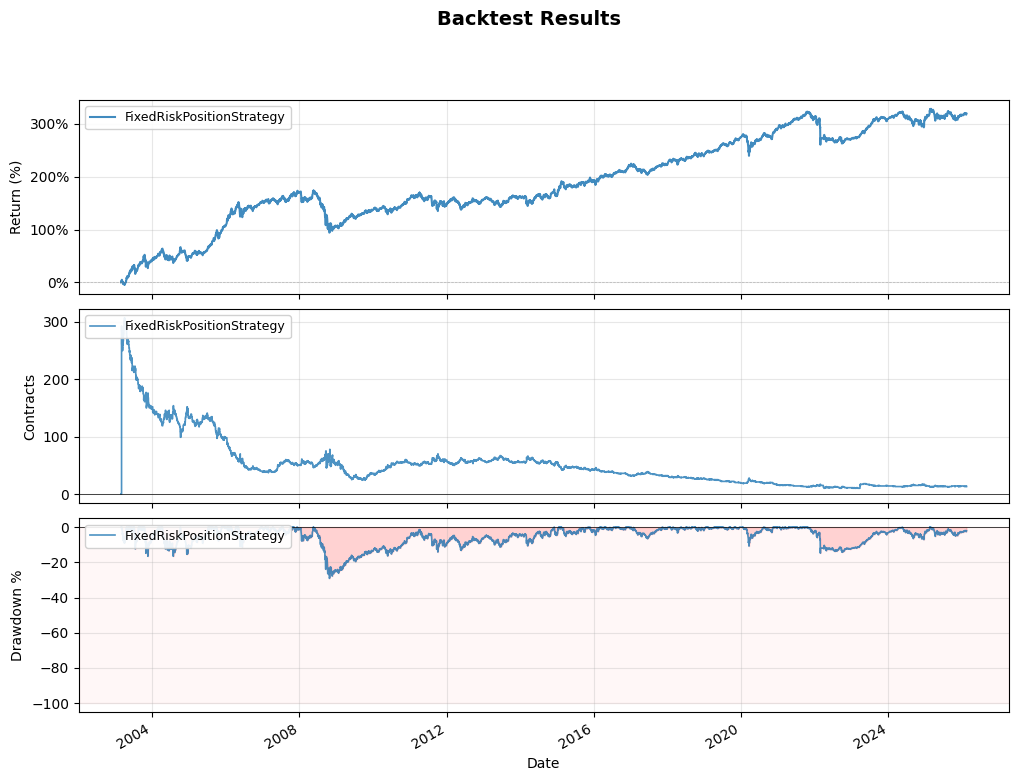

In [11]:
plot_results(strategy_risky_result, plot_pct=True)

c:\Users\igor\Documents\GitHub\futures_trading_strategies\src\plots\plot_backtest_results.py:174: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


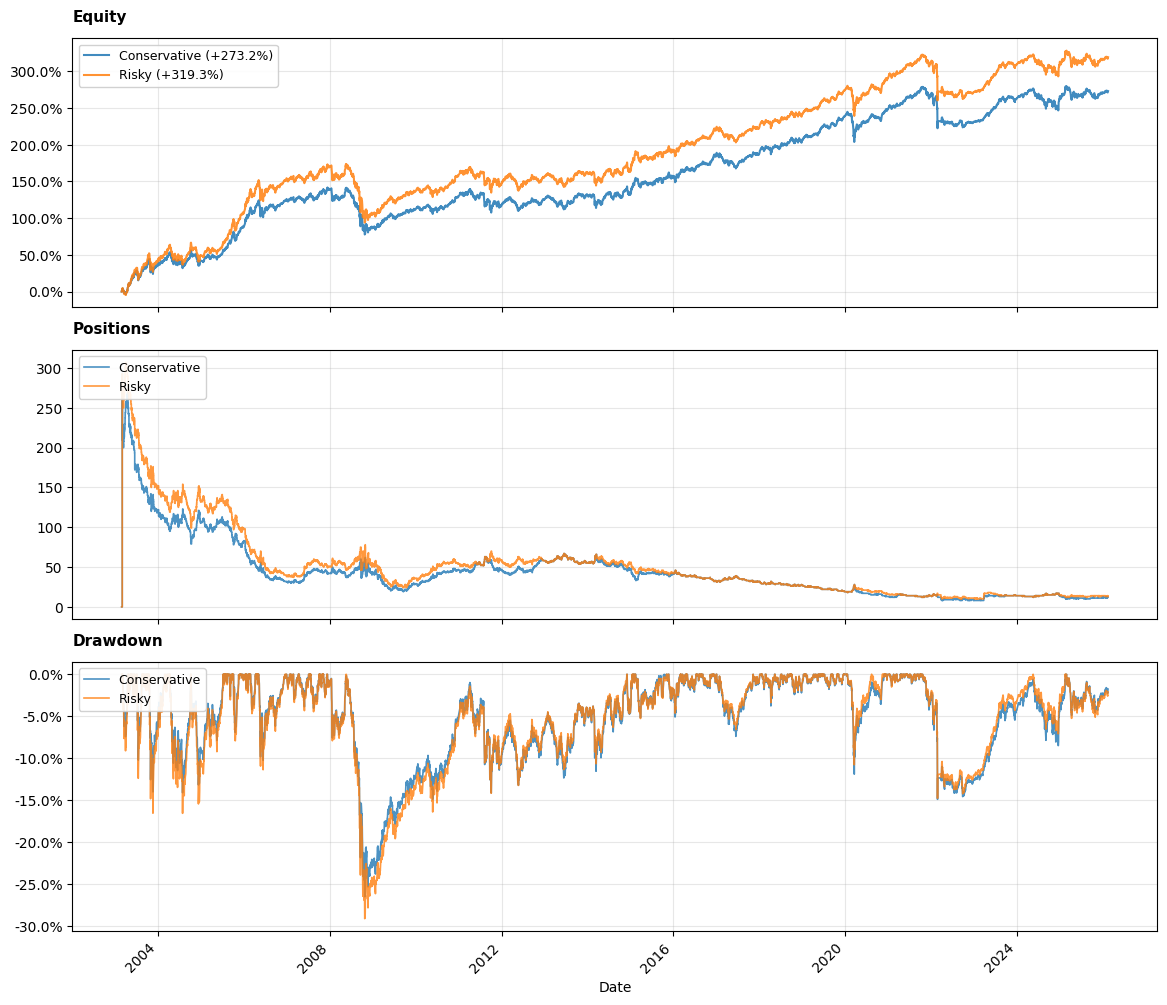

In [12]:
plot_backtest_results({"Conservative": strategy_fixed_result, "Risky": strategy_risky_result}, plot_pct=True)

c:\Users\igor\Documents\GitHub\futures_trading_strategies\src\plots\plot_backtest_results.py:174: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


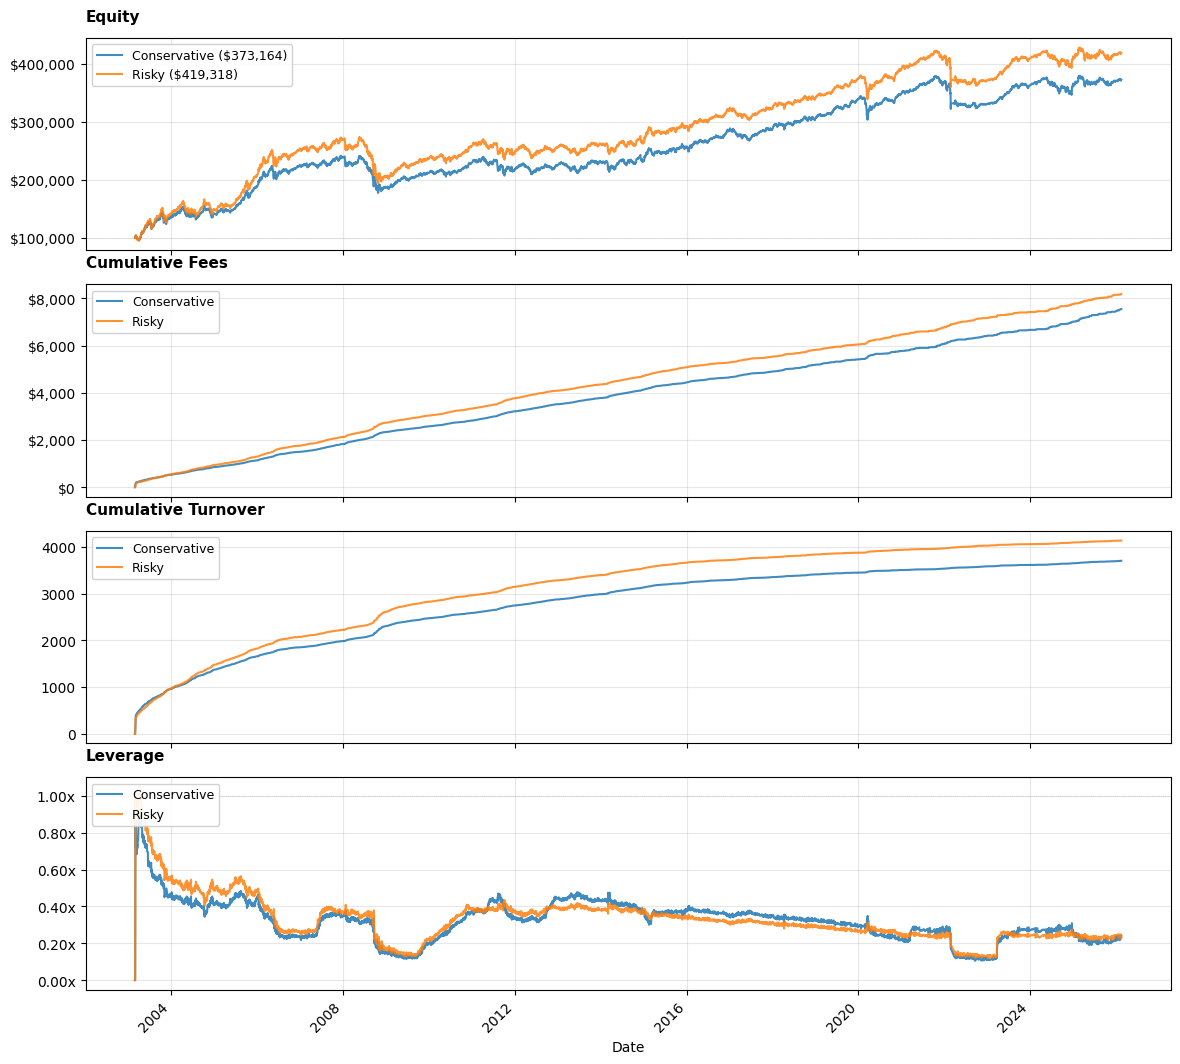

In [13]:
plot_backtest_results(
    results={"Conservative": strategy_fixed_result, "Risky": strategy_risky_result},
    panels=['equity', 'cumulative_fees', 'cumulative_turnover', 'leverage'],
    data=data,
    plot_pct=False,
    figsize_base=(14, 2.8)  # Slightly taller panels
)

In [14]:
# 1. Quick DataFrame for Jupyter display
from src import compare_strategies, print_comparison_table
comparison_df = compare_strategies({"Conservative": strategy_fixed_result, "Risky": strategy_risky_result})
display(comparison_df)


,Conservative,Risky
Total Return %,+273.16%,+319.32%
CAGR %,+5.95%,+6.50%
Gross Return %,+280.71%,+327.50%
Annual Vol %,+9.16%,+9.97%
Max Drawdown %,-26.51%,-29.12%
Avg Drawdown %,-1.60%,-1.75%
Sharpe Ratio,0.65,0.65
Gross Sharpe,0.66,0.66
Turnover-Adj Sharpe,0.59,0.58
Sharpe Drag,0.01,0.01


In [15]:
print_comparison_table({"Conservative": strategy_fixed_result, "Risky": strategy_risky_result}, title="Vol-Adjusted B&H Comparison")

┌─────────────────────────────────────────────────┐
│            Vol-Adjusted B&H Comparison            │
├──────────────────────┼──────────────┼───────────┤
│ Metric               │ Conservative │ Risky     │
├──────────────────────┼──────────────┼───────────┤
│ 📈 Returns & Performance │                           │
│ Total Return %       │ +273.16%     │ +319.32%  │
│ CAGR %               │ +5.95%       │ +6.50%    │
│ Gross Return %       │ +280.71%     │ +327.50%  │
├──────────────────────┼──────────────┼───────────┤
│ ⚠️ Risk & Volatility │                           │
│ Annual Vol %         │ +9.16%       │ +9.97%    │
│ Max Drawdown %       │ -26.51%      │ -29.12%   │
│ Avg Drawdown %       │ -1.60%       │ -1.75%    │
├──────────────────────┼──────────────┼───────────┤
│ 🎯 Risk-Adjusted Returns │                           │
│ Sharpe Ratio         │ 0.65         │ 0.65      │
│ Gross Sharpe         │ 0.66         │ 0.66      │
│ Turnover-Adj Sharpe  │ 0.59         │ 0.58      │
│